# Домашнее задание к семинару 02 (HW02)

## Тема: работа с табличными данными в Pandas, контроль качества данных, базовый EDA и визуализация в Matplotlib.

#### 2.3.1. Загрузка данных и первичный осмотр

1. Импортировать необходимые библиотеки:
   - `pandas` (обязательно),
   - при необходимости `numpy`,
   - `matplotlib.pyplot` для визуализации.

In [248]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2. Загрузить учебный датасет в `pandas.DataFrame` с помощью `pd.read_csv` (или другого подходящего метода).

In [249]:
data = pd.read_csv("S02-hw-dataset.csv")

3. Вывести:
   - первые строки датасета (`head()`),
   - информацию о столбцах и типах (`info()`),
   - базовые описательные статистики (`describe()` или аналог).


In [250]:
data.head(10)


,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115
2,3,52.0,FR,7,399
3,4,31.0,RU,6,654
4,5,NaN,DE,6,1296
5,6,120.0,FR,-1,785
6,7,46.0,RU,0,0
7,8,28.0,CN,2,456
8,9,39.0,US,4,980
9,10,24.0,RU,7,511


In [251]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    41 non-null     int64  
 1   age        39 non-null     float64
 2   country    41 non-null     object 
 3   purchases  41 non-null     int64  
 4   revenue    41 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.7+ KB


In [252]:
data.describe()

,user_id,age,purchases,revenue
count,41.000000,39.000000,41.000000,41.000000
mean,20.243902,36.512821,4.829268,820.048780
std,11.659289,18.304259,2.710189,613.127269
min,1.000000,5.000000,-1.000000,0.000000
25%,10.000000,24.000000,3.000000,432.000000
50%,20.000000,33.000000,5.000000,693.000000
75%,30.000000,45.500000,7.000000,1115.000000
max,40.000000,120.000000,11.000000,2475.000000


#### 2.3.2. Пропуски, дубликаты и базовый контроль качества

1. Посчитать долю пропусков в каждом столбце (например, через `isna().mean()` или аналог).

In [253]:
data.isna().mean()

user_id      0.00000
age          0.04878
country      0.00000
purchases    0.00000
revenue      0.00000
dtype: float64

2. Проверить наличие полностью дублирующих строк (через `duplicated()`).

In [254]:
data.duplicated()


0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40     True
dtype: bool

In [255]:
count_duplicates = data.duplicated().sum()
print(f"Количество дубликатов: {count_duplicates}")

Количество дубликатов: 1


In [256]:
duplicate_rows = data[data.duplicated()]
duplicate_rows

,user_id,age,country,purchases,revenue
40,10,24.0,RU,7,511


3. Найти и вывести «подозрительные» случаи, исходя из смысла датасета. Примеры:
   - отрицательные значения в полях, где их не должно быть (количество, цена и т.п.);
   - нереалистичные значения (например, возраст > 100, нулевой доход при ненулевых количествах и т.п.);
   - другие логические противоречия, характерные для конкретного датасета.

In [257]:
data

,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115
2,3,52.0,FR,7,399
3,4,31.0,RU,6,654
4,5,NaN,DE,6,1296
5,6,120.0,FR,-1,785
6,7,46.0,RU,0,0
7,8,28.0,CN,2,456
8,9,39.0,US,4,980
9,10,24.0,RU,7,511


In [258]:
data[data.duplicated()]


,user_id,age,country,purchases,revenue
40,10,24.0,RU,7,511


In [259]:
heh = data[(data['age'] < 0) | (data['purchases'] < 0) | (data['revenue'] < 0) | (data['age'] > 100) | (data['age'] < 10) ]
heh

,user_id,age,country,purchases,revenue
5,6,120.0,FR,-1,785
20,21,5.0,RU,8,1488


In [260]:
hoh = data[(data["revenue"] <= 0) & (data["purchases"] > 0)]
hoh

,user_id,age,country,purchases,revenue
10,11,24.0,US,4,0


In [261]:
lol = data[data["age"].isnull()]
lol

,user_id,age,country,purchases,revenue
4,5,NaN,DE,6,1296
12,13,NaN,US,9,630


4. Кратко (1-2 абзаца) описать текстом, какие проблемы качества данных были обнаружены.

Есть строки, где
1) Возраст 120 лет ( как будто вряд ли человек будет в 120 лет самостоятельно совершать покупки)
2) Возраст 5 лет (вряд ли в 5 лет человек может совершать покупки, это еще ребенок)
3) Значение покупки (purchases) отрицательное (сомнительно)
4) Значение покупок (purchases) положительное, а доход (revenue) нулевой (тоже сомнительно)
5) Возраст NaN (скрытность возраста)
6) дублирующиеся строки с user_id = 10

#### 2.3.3. Базовый EDA: группировки, агрегаты и частоты

1. Посчитать частоты для одной или двух категориальных переменных (например, `value_counts()` для столбца с категорией/страной/классом).

In [262]:
print("Частоты по странам:")
print(data['country'].value_counts())

Частоты по странам:
country
RU    13
FR    12
US     8
DE     6
CN     2
Name: count, dtype: int64


In [263]:
print("Частоты по ворасту:")
print(data['age'].value_counts())

Частоты по ворасту:
age
24.0     5
52.0     2
31.0     2
28.0     2
39.0     2
35.0     2
47.0     2
32.0     2
25.0     1
55.0     1
43.0     1
45.0     1
26.0     1
23.0     1
51.0     1
18.0     1
54.0     1
5.0      1
21.0     1
42.0     1
33.0     1
22.0     1
57.0     1
36.0     1
20.0     1
46.0     1
120.0    1
34.0     1
Name: count, dtype: int64


2. Выполнить хотя бы одну осмысленную группировку с агрегатами через `groupby`:
   - например, среднее и сумму по количественным признакам в разрезе категорий.

In [264]:
grouped = data.groupby('country').agg(
    count_users=('user_id', 'count'),
    avg_age=('age', 'mean'),
    avg_purchases=('purchases', 'mean'),
    total_revenue=('revenue', 'sum'),
    avg_revenue=('revenue', 'mean')
)
grouped

,count_users,avg_age,avg_purchases,total_revenue,avg_revenue
country,,,,,
CN,2,24.000000,4.500000,2108,1054.000000
DE,6,34.600000,6.500000,8673,1445.500000
FR,12,46.250000,4.250000,8111,675.916667
RU,13,30.076923,4.769231,10271,790.076923
US,8,36.714286,4.625000,4459,557.375000


3. При необходимости ввести дополнительные «коридоры» (bins) или группировки (например, возрастные группы, диапазоны значений и т.п.).

In [265]:
bins = [0, 25, 40, 55, 130]
labels = ['18-25', '26-40', '41-55', '56+']
data['age_group'] = pd.cut(data['age'], bins=bins, labels=labels, right=False)
data


,user_id,age,country,purchases,revenue,age_group
0,1,25.0,FR,7,749,26-40
1,2,24.0,RU,5,1115,18-25
2,3,52.0,FR,7,399,41-55
3,4,31.0,RU,6,654,26-40
4,5,NaN,DE,6,1296,NaN
5,6,120.0,FR,-1,785,56+
6,7,46.0,RU,0,0,41-55
7,8,28.0,CN,2,456,26-40
8,9,39.0,US,4,980,26-40
9,10,24.0,RU,7,511,18-25


In [266]:
print("\nРаспределение по возрастным группам:")
print(data['age_group'].value_counts().sort_index())



Распределение по возрастным группам:
age_group
18-25    11
26-40    15
41-55    10
56+       3
Name: count, dtype: int64


In [267]:
print("\nСтатистика по возрастным группам:")
age_grouped = data.groupby('age_group').agg(
    count_users=('user_id', 'count'),
    avg_purchases=('purchases', 'mean'),
    avg_revenue=('revenue', 'mean')
)
age_grouped


Статистика по возрастным группам:


/var/folders/j1/6gqv04xj53d1zk9jjc92dmf80000gn/T/ipykernel_7037/212014731.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_grouped = data.groupby('age_group').agg(


,count_users,avg_purchases,avg_revenue
age_group,,,
18-25,11,5.000000,696.272727
26-40,15,5.400000,1044.266667
41-55,10,4.000000,675.300000
56+,3,2.333333,540.000000


4. Кратко (1-2 абзаца) описать текстом основные наблюдения:
   - какие категории доминируют,
   - как отличаются группы по средним значениям,
   - есть ли неожиданные эффекты.

В датасете преобладают пользователи из России (13 человек), однако по среднему доходу на пользователя лидируют Германия (1445) и Китай (1054) — это указывает на то, что качество клиентов важнее их количества.  Штаты показывают самый низкий доход.

По возрасту наиболее масштабной аудиторией являются пользователи 26–40 лет, они совершают больше всего покупок (в среднем 5.4) и приносят наибольший доход (1044). При этом молодёжь (18–25) почти не уступает по активности, но имеет более низкую ценность. Старшие группы (56+) значительно уступают по обоим показателям.

### 2.4. Визуализация данных в Matplotlib

1. **Одну гистограмму** для количественного признака:
   - осмысленный выбор числа корзин (`bins`),
   - подписи осей и заголовок.

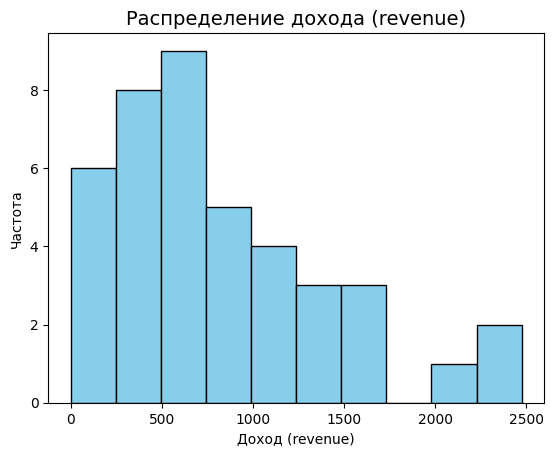

In [268]:
plt.hist(data['revenue'], bins=10, edgecolor='black', color='skyblue')
plt.title('Распределение дохода (revenue)', fontsize=14)
plt.xlabel('Доход (revenue)')
plt.ylabel('Частота')
plt.show()

Доход распределён неравномерно: большинство пользователей приносят доход в диапазоне 0–1000, с пиком около 500–750. Есть небольшое количество «высокодоходных» клиентов (до 2500). 

2. **Один боксплот (boxplot)** для количественного признака:
   - можно как общий, так и по группам (например, по категориям),
   - подписи оси и заголовок.


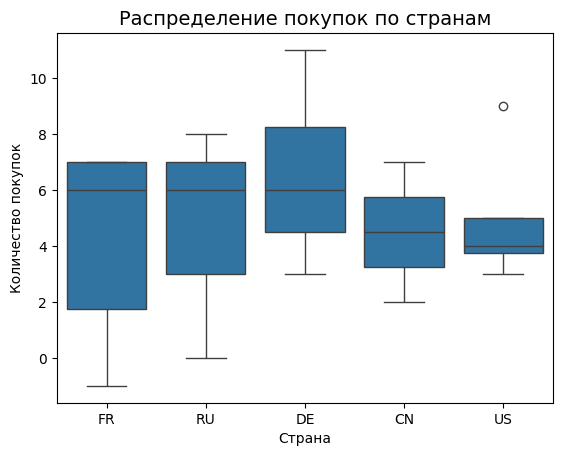

In [269]:
sns.boxplot(data=data, x='country', y='purchases')
plt.title('Распределение покупок по странам', fontsize=14)
plt.xlabel('Страна')
plt.ylabel('Количество покупок')
plt.show()

На графике видно, что медианное количество покупок самое высокое у пользователей из Германии (DE) — около 6. У России (RU) и Франции (FR) медиана около 6, но с большим разбросом.
Важно: в Германии есть один выброс сверху — пользователь совершил более 10 покупок.

3. **Один scatter plot** (диаграмма рассеяния) для пары количественных признаков:
   - подписи обеих осей,
   - заголовок,
   - при желании можно добавить цвет/легенду для различения категорий.

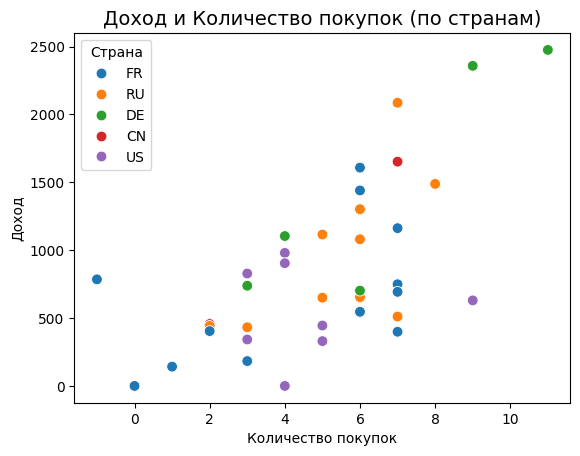

In [270]:
sns.scatterplot(data=data, x='purchases', y='revenue', hue='country', s=60)
plt.title('Доход и Количество покупок (по странам)', fontsize=14)
plt.xlabel('Количество покупок')
plt.ylabel('Доход')
plt.legend(title='Страна')
plt.show()

Чётко видна положительная корреляция: чем больше покупок — тем выше доход. Пользователи из Германии (зелёный) и Китая (красный) тяготеют к верхнему правому углу — высокие показатели по обоим параметрам. Американцы (фиолетовый) — чаще в нижней части — скромный доход при умеренном числе покупок